# AG-HYPOPT · Trial 16

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

[Fifteen trials recorded; best is trial 14 (0.0149), with trial 12 (0.0150) tied. Sequence: 01 0.0981, 02 0.0246, 03 0.0477, 04 0.0262, 05 0.0196, 06 0.0329, 07 0.0205, 08 0.0294, 09 0.0182, 10 0.0301, 11 0.0174, 12 0.0150, 13 0.0339, 14 0.0149, 15 0.0199. Trials 05/07/08/09/10/11/12/13/14/15 are the same plateau point (lr_mu ~27, sigma_ref ~6.05-6.3, lr_gamma ~0.42, gamma_anneal ~0.37-0.43) spanning 0.0149-0.0339. mu is tightly bounded at 14.4-17.2%; gamma ranges 9.5-21.4% and drives all the spread through the Trans05 scans. The best runs (12, 14) are at sigma_ref ~6.09 with gamma under 10%, but trial 15 (sigma_ref 6.05) gave 13.6%, so sigma_ref below 6.1 does not reliably help - the gamma noise dominates. lr_mu peaks near 27, sigma_ref monotone but saturated around 6.1. We are in the TPE phase (16th trial).]


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_16'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 20    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (15/5 trials)
ID |     ei | params
 1 | 3.0142 | {"gamma_anneal": 0.4328341364313741, "lr_gamma": 0.4784636403487964, "lr_mu": 26.921321746516735, "sigma_ref": 6.211637147513954}
 2 | 0.3035 | {"gamma_anneal": 0.6018157221494281, "lr_gamma": 0.7564991319188754, "lr_mu": 22.290493899581662, "sigma_ref": 6.21013803323797}
 3 | 3.9998 | {"gamma_anneal": 0.4195702710239643, "lr_gamma": 0.4173470745659063, "lr_mu": 27.1059276796649, "sigma_ref": 6.098961279863172}
 4 | 3.9228 | {"gamma_anneal": 0.2885561338991415, "lr_gamma": 0.41758787633866196, "lr_mu": 26.87975056915263, "sigma_ref": 19.597697160933443}
 5 | 3.9896 | {"gamma_anneal": 0.4089829750821488, "lr_gamma": 0.9795992965392009, "lr_mu": 27.044947283364635, "sigma_ref": 6.202939177678276}
 6 | 3.9997 | {"gamma_anneal": 0.4226588666176254, "lr_gamma": 0.41784487622951977, "lr_mu": 26.942394397435823, "sigma_ref": 6.178833168121132}
 7 | 3.9982 | {"gamma_anneal": 0.7419022300167575, "lr_gamma": 0.4175818730161294, "lr

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

[Best is trial 14 (0.0149), tied with trial 12 (0.0150); the plateau is settled at lr_mu ~27, sigma_ref ~6.1, lr_gamma ~0.42, gamma_anneal ~0.42, with the objective set by the Trans05 gamma noise (9.5-21.4%) on top of a fixed mu floor (14.4-17.2%). The TPE batch proposes the plateau again: the top-ei draws are #3 (ei 3.9998, lr_mu 27.11, sigma_ref 6.099), #6 (ei 3.9997, sigma_ref 6.179) and #7 (ei 3.9982, gamma_anneal 0.742); the off-plateau draws raise sigma_ref or drop lr_mu. The sensible choice is the top draw, candidate 3, which sits exactly at the 6.09 sigma_ref edge where trials 12/14 recorded the best objectives and at the optimal lr_mu - a repeat of the best-known configuration, which the campaign must do because run-to-run noise exceeds the tunable effects. I choose candidate 3.]


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 3               # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'gamma_anneal': 0.4195702710239643, 'lr_gamma': 0.4173470745659063, 'lr_mu': 27.1059276796649, 'sigma_ref': 6.098961279863172}
Running  1nW Trans05 ... 

μ 9.39 -> 6.90 | γ 8.5 -> 6.87 | NLL 1.32


Running  1nW Trans20 ... 

μ 17.32 -> 15.87 | γ 8.5 -> 7.89 | NLL 2.76


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 99.23 | γ 14.1 -> 13.85 | NLL 3.45


Running 3nW Trans100 ... 

μ 175.71 -> 164.68 | γ 14.1 -> 13.80 | NLL 2.91



Total: 7.0 min


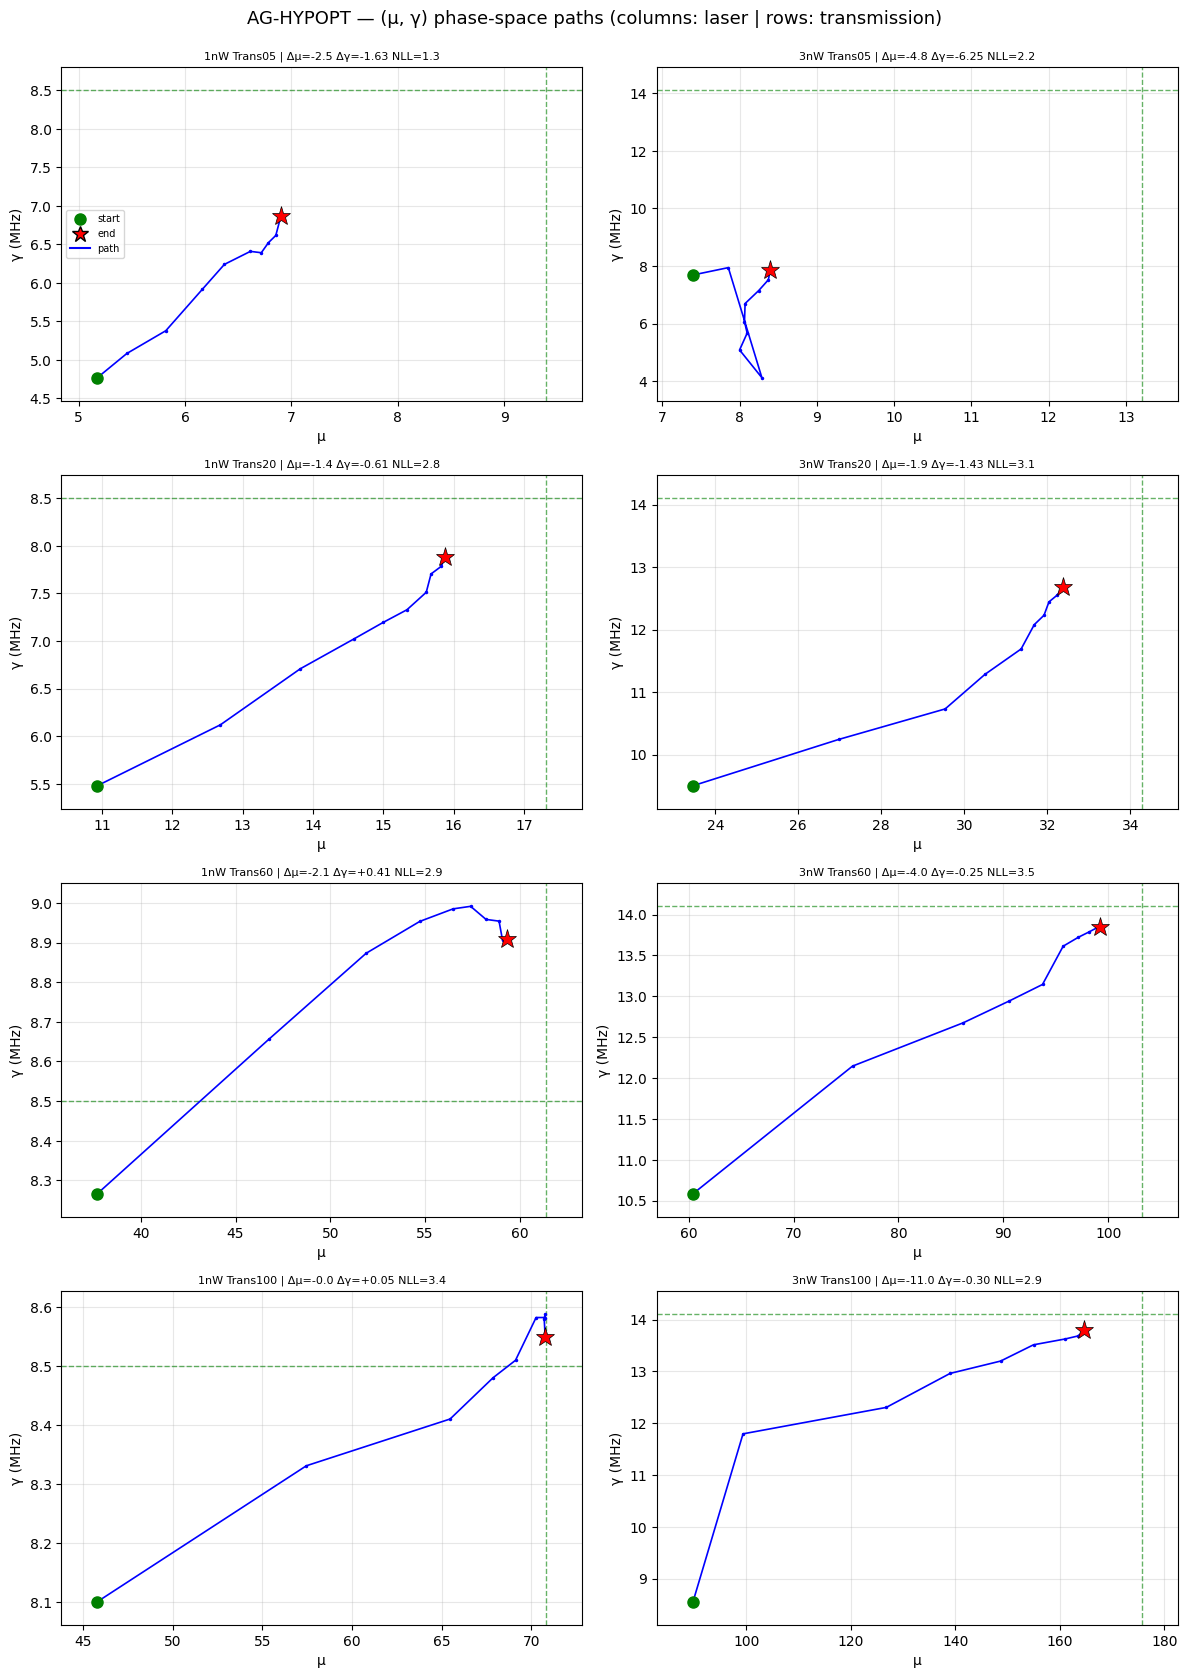

trial finished in 7.0 min
objective = 0.0294 ± 0.0142
exp           μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05     9.39    6.90   -26.5 |     8.50    6.87   -19.2
1nW Trans20    17.32   15.87    -8.3 |     8.50    7.89    -7.2
1nW Trans60    61.37   59.30    -3.4 |     8.50    8.91    +4.8
1nW Trans100   70.82   70.77    -0.1 |     8.50    8.55    +0.6
3nW Trans05    13.20    8.40   -36.4 |    14.10    7.85   -44.3
3nW Trans20    34.28   32.39    -5.5 |    14.10   12.67   -10.1
3nW Trans60   103.20   99.23    -3.8 |    14.10   13.85    -1.8
3nW Trans100  175.71  164.68    -6.3 |    14.10   13.80    -2.2

μ: RMSE 4.700 (rel 16.6%, bias -3.470) | γ: RMSE 2.356 (rel 17.7%, bias -1.251)


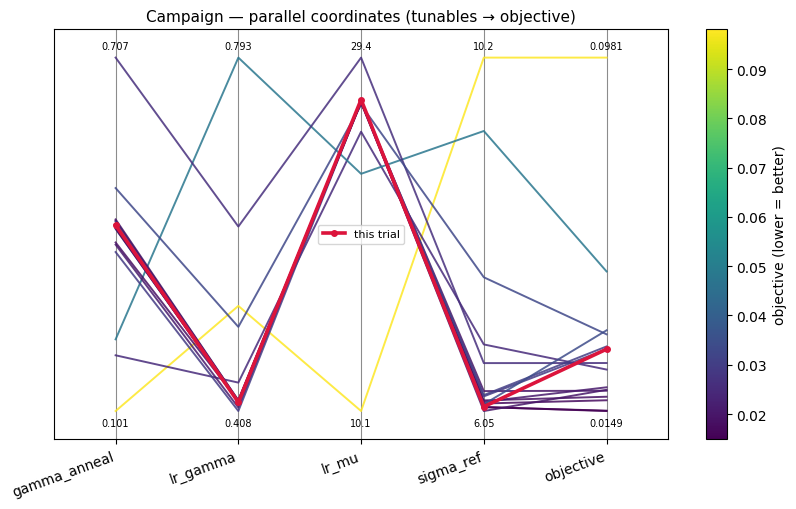

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 16 (sigma_ref 6.099, lr_mu 27.11, lr_gamma 0.417, gamma_anneal 0.420), the top-ei plateau draw at the 6.09 edge, ran 7.0 min and scored 0.0294 +/- 0.0142, another mid-range plateau result: mu 16.6% and gamma 17.7%, with both hurt by the 3nW Trans05 scan (mu -36.4%, gamma -44.3%). It is essentially the trial 12/14 config but the low-count 3nW Trans05 run came out badly, unlike the 1nW Trans05 collapse of trial 13 - so the erratic scan can be either Trans05 point. Eight runs of the plateau (trials 05/07/08/09/10/11/12/13/14/15/16) now span 0.0149-0.0339, all with mu 14.4-17.2%, and the best remains trial 14 (0.0149). The campaign has converged; nothing in the tunable set moves the mu floor or stabilises the Trans05 gamma.

**Summary:** Trial 16 (sigma_ref 6.099, lr_mu 27.11, lr_gamma 0.417, gamma_anneal 0.420) scored 0.0294 +/- 0.0142, a mid-range plateau result: mu 16.6% and gamma 17.7%, both dragged by a bad 3nW Trans05 run (gamma -44.3%).
**Key insight:** The erratic low-count Trans05 scan (1nW or 3nW) is the sole driver of plateau objective variance; mu stays at 14.4-17.2% and trial 14 (0.0149) remains best.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
[Notes for Anuar: none this trial.]


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'Trial 16 (sigma_ref 6.099, lr_mu 27.11, lr_gamma 0.417, gamma_anneal 0.420) scored 0.0294 +/- 0.0142, a mid-range plateau result: mu 16.6% and gamma 17.7%, both dragged by a bad 3nW Trans05 run (gamma -44.3%).'
KEY_INSIGHT = 'The erratic low-count Trans05 scan (1nW or 3nW) is the sole driver of plateau objective variance; mu stays at 14.4-17.2% and trial 14 (0.0149) remains best.'


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_16 | current best: trial_14


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_17.ipynb. Open it and follow its cells from the top.
